# **Credit Card Fraud Detection Using Machine Learning**

## Dataset Overview

- Total Transactions: 284,807
- Total Features: 31
- Fraud Transactions: 492
- Normal Transactions: 284,315

Target Variable:
- 0 = Legitimate Transaction
- 1 = Fraudulent Transaction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [1]:
from google.colab import files
uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [4]:
df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Exploratory Data Analysis

### Key Findings

- No missing values were found.
- Dataset is highly imbalanced.
- Fraudulent transactions account for approximately 0.17% of all transactions.

In [6]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


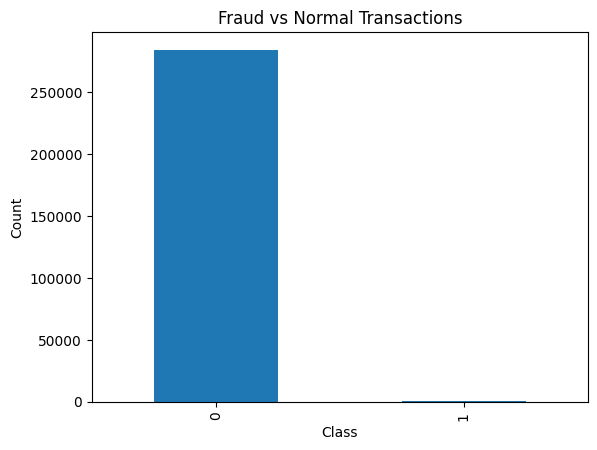

In [7]:
df['Class'].value_counts().plot(kind='bar')

plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

In [8]:
X = df.drop('Class', axis=1)
y = df['Class']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [10]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Accuracy: 0.9989466661985184
Precision: 0.8275862068965517
Recall: 0.4897959183673469
F1 Score: 0.6153846153846154


In [14]:
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.9995435553526912
Precision: 0.9736842105263158
Recall: 0.7551020408163265
F1 Score: 0.8505747126436781


In [16]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[56862     2]
 [   24    74]]


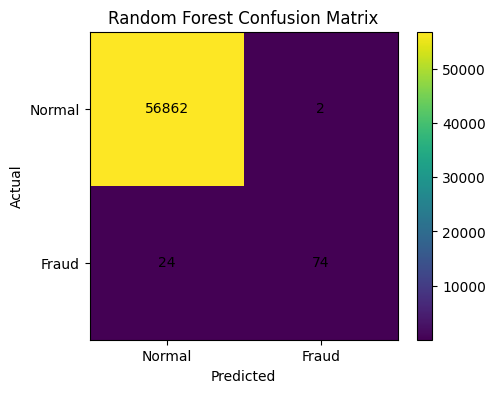

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1], ['Normal','Fraud'])
plt.yticks([0,1], ['Normal','Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.show()

## Results

| Metric | Logistic Regression | Random Forest |
|----------|----------|----------|
| Accuracy | 99.89% | 99.95% |
| Precision | 82.76% | 97.37% |
| Recall | 48.98% | 75.51% |
| F1 Score | 61.54% | 85.06% |

Two machine learning models were evaluated for fraud detection: Logistic Regression and Random Forest. Due to the highly imbalanced nature of the dataset, evaluation focused on precision, recall, and F1 score rather than accuracy alone. Random Forest significantly outperformed Logistic Regression, achieving higher precision, recall, and F1 score. Therefore, Random Forest was selected as the preferred model for detecting fraudulent transactions.## Conclusion

Random Forest outperformed Logistic Regression across all evaluation metrics.

The model achieved:

- Precision: 97.37%
- Recall: 75.51%
- F1 Score: 85.06%

Random Forest was selected as the final model because it identified fraudulent transactions more effectively.